# 08c — ESM-2 + ProteinMPNN Integrated Candidate Selection

## Pipeline 4 — AI-guided peptide design

This notebook integrates the two AI components introduced in Pipeline 4:

```text
08a  ESM-2 sequence plausibility
08b  ProteinMPNN structure-conditioned design
```

with the established PEARL reference candidates:

```text
F0010 = IGERCQYRDLK
CF06  = IGERCQYRELR
CF02  = IGERSQYRELK
```

The main purpose is:

> Reduce the ProteinMPNN production set to a small, interpretable group of new peptide candidates for structural validation.

---

## Decision logic

For every unique ProteinMPNN peptide we evaluate:

```text
ProteinMPNN score
+
ProteinMPNN sampling frequency
+
ESM-2 masked pseudo-log-likelihood
+
sequence locality vs F0010
+
overlap with previous local/CLEAR sequence space
```

The notebook then selects **3–5 candidates** using complementary criteria rather than simply taking the first rows of one score.

---

## Important limitation

This notebook performs **AI-level prioritization**.

New ProteinMPNN candidates have not yet received:
- FoldX validation;
- Rosetta refinement;
- molecular dynamics;
- endpoint energetic analysis.

Therefore they must not yet be compared biologically on equal footing with CF06/CF02, which have already passed those downstream stages.
** ATTENTION : Python (PEARL AI) execution kernel

## 1. Environment check

In [1]:
import sys
from pathlib import Path

print("Python:", sys.version)
print("Working directory:", Path.cwd())

try:
    import torch
    import esm
    print("PyTorch:", torch.__version__)
    print("fair-esm: OK")
except Exception as exc:
    raise RuntimeError(
        "Use the Python (PEARL AI) kernel used for 08a/08b. "
        f"Import error: {exc}"
    )


Python: 3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:29:05) [Clang 19.1.7 ]
Working directory: /Users/robertobruzzese/Desktop/venv
PyTorch: 2.13.0
fair-esm: OK


## 2. Imports

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 250)

print("Imports OK")


Imports OK


## 3. Device and configuration

In [3]:
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

MODEL_NAME = "esm2_t6_8M_UR50D"

REFERENCE_SEQUENCES = {
    "F0010": "IGERCQYRDLK",
    "CF06": "IGERCQYRELR",
    "CF02": "IGERSQYRELK",
}

SEED_SEQUENCE = REFERENCE_SEQUENCES["F0010"]

INPUT_08B = (
    Path("outputs")
    / "pipeline_4_ai_08b_proteinmpnn"
    / "production"
    / "tables"
    / "08b_ProteinMPNN_unique_designs.csv"
)

OUTPUT_ROOT = (
    Path("outputs")
    / "pipeline_4_ai_08c_integrated_candidate_selection"
)

TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [OUTPUT_ROOT, TABLE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Selection parameters.
MAX_HAMMING_ALLOWED = 4
MAX_HAMMING_CONSERVATIVE = 3
N_FINAL_MIN = 3
N_FINAL_MAX = 5

print("Device:", DEVICE)
print("Model:", MODEL_NAME)
print("08b input:", INPUT_08B)
print("Output:", OUTPUT_ROOT.resolve())


Device: mps
Model: esm2_t6_8M_UR50D
08b input: outputs/pipeline_4_ai_08b_proteinmpnn/production/tables/08b_ProteinMPNN_unique_designs.csv
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08c_integrated_candidate_selection


## 4. Load the ProteinMPNN production set

In [4]:
if not INPUT_08B.exists():
    raise FileNotFoundError(
        "08b production unique-design table not found:\n"
        f"{INPUT_08B}"
    )

mpnn_df = pd.read_csv(INPUT_08B)

required_columns = [
    "peptide_sequence",
    "sample_count",
    "best_ProteinMPNN_score",
    "mean_ProteinMPNN_score",
    "min_hamming_vs_F0010",
]

missing = [
    c for c in required_columns
    if c not in mpnn_df.columns
]

if missing:
    raise RuntimeError(
        f"08b table is missing columns: {missing}"
    )

print("Unique ProteinMPNN production designs:", len(mpnn_df))

display(
    mpnn_df.head(30)
)


Unique ProteinMPNN production designs: 24


,ProteinMPNN_rank,peptide_sequence,sample_count,best_ProteinMPNN_score,mean_ProteinMPNN_score,best_global_score,min_hamming_vs_F0010,matches_F0010,matches_CF06,matches_CF02
0,1,TGPRNQYRDLP,34,1.2473,1.300118,1.5296,4,False,False,False
1,2,TGPRNQYRDLN,25,1.2479,1.305864,1.5373,4,False,False,False
2,3,TGPRNQYRDLG,14,1.2572,1.321343,1.5397,4,False,False,False
3,4,VGPRNQYRDLP,3,1.2978,1.314500,1.5479,4,False,False,False
4,5,IGPRNQYRDLN,2,1.3458,1.374800,1.5526,3,False,False,False
5,6,VGPRNQYRDLN,2,1.3525,1.376000,1.5445,4,False,False,False
6,7,TGPRNQYRDLS,2,1.3576,1.360850,1.5393,4,False,False,False
7,8,IGPRNQYRDLG,1,1.3662,1.366200,1.5476,3,False,False,False
8,9,TGPRNQYRDLT,2,1.3831,1.422550,1.5397,4,False,False,False
9,10,IGPRNQYRDLP,1,1.3881,1.388100,1.5462,3,False,False,False


## 5. Basic sequence QC

In [5]:
VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")

mpnn_df["valid_sequence"] = (
    mpnn_df["peptide_sequence"]
    .astype(str)
    .apply(
        lambda seq: (
            len(seq) == len(SEED_SEQUENCE)
            and set(seq).issubset(VALID_AA)
        )
    )
)

if not mpnn_df["valid_sequence"].all():
    display(
        mpnn_df[
            ~mpnn_df["valid_sequence"]
        ]
    )
    raise RuntimeError(
        "One or more ProteinMPNN designs failed sequence QC."
    )

print("Sequence QC: PASS")


Sequence QC: PASS


## 6. Recalculate locality and mutation patterns

In [6]:
def hamming_distance(a, b):
    if len(a) != len(b):
        return np.nan
    return sum(
        aa != bb
        for aa, bb in zip(a, b)
    )

def mutation_string(
    reference,
    sequence,
):
    changes = []

    for pos, (a, b) in enumerate(
        zip(reference, sequence),
        start=1,
    ):
        if a != b:
            changes.append(
                f"{a}{pos}{b}"
            )

    return "+".join(changes) if changes else "WT"

mpnn_df["hamming_vs_F0010_recalc"] = (
    mpnn_df["peptide_sequence"]
    .apply(
        lambda seq: hamming_distance(
            SEED_SEQUENCE,
            seq,
        )
    )
)

mpnn_df["mutations_vs_F0010"] = (
    mpnn_df["peptide_sequence"]
    .apply(
        lambda seq: mutation_string(
            SEED_SEQUENCE,
            seq,
        )
    )
)

mpnn_df["within_allowed_locality"] = (
    mpnn_df["hamming_vs_F0010_recalc"]
    <= MAX_HAMMING_ALLOWED
)

display(
    mpnn_df[
        [
            "peptide_sequence",
            "mutations_vs_F0010",
            "hamming_vs_F0010_recalc",
            "sample_count",
            "best_ProteinMPNN_score",
        ]
    ]
    .sort_values(
        [
            "hamming_vs_F0010_recalc",
            "best_ProteinMPNN_score",
        ]
    )
    .head(30)
)


,peptide_sequence,mutations_vs_F0010,hamming_vs_F0010_recalc,sample_count,best_ProteinMPNN_score
4,IGPRNQYRDLN,E3P+C5N+K11N,3,2,1.3458
7,IGPRNQYRDLG,E3P+C5N+K11G,3,1,1.3662
9,IGPRNQYRDLP,E3P+C5N+K11P,3,1,1.3881
14,IGPRHQYRDLP,E3P+C5H+K11P,3,1,1.4079
19,IGPRNQYRDLT,E3P+C5N+K11T,3,1,1.5206
0,TGPRNQYRDLP,I1T+E3P+C5N+K11P,4,34,1.2473
1,TGPRNQYRDLN,I1T+E3P+C5N+K11N,4,25,1.2479
2,TGPRNQYRDLG,I1T+E3P+C5N+K11G,4,14,1.2572
3,VGPRNQYRDLP,I1V+E3P+C5N+K11P,4,3,1.2978
5,VGPRNQYRDLN,I1V+E3P+C5N+K11N,4,2,1.3525


## 7. Search previous PEARL local sequence space

This section checks whether a ProteinMPNN sequence was already present in the
539-variant local dataset from 04c.

It searches several likely CSV files and automatically identifies a sequence
column.

Being present in 04c does **not** mean that ProteinMPNN copied the sequence;
it only tells us whether the proposal lies inside previously enumerated local
sequence space.


In [7]:
LOCAL_DATASET_CANDIDATES = [
    Path(
        "outputs/clear_local_peptide_dataset_04c/"
        "clear_local_peptide_variant_dataset_labeled.csv"
    ),
    Path(
        "outputs/clear_local_peptide_dataset_04c/"
        "clear_local_peptide_variant_dataset.csv"
    ),
]

local_dataset_file = next(
    (
        p for p in LOCAL_DATASET_CANDIDATES
        if p.exists()
    ),
    None,
)

local_sequence_set = set()
local_dataset_df = None

if local_dataset_file is None:
    print("04c local dataset CSV not found automatically.")
else:
    local_dataset_df = pd.read_csv(
        local_dataset_file
    )

    seq_col = next(
        (
            c for c in [
                "sequence",
                "peptide_sequence",
                "variant_sequence",
                "seq",
            ]
            if c in local_dataset_df.columns
        ),
        None,
    )

    print("04c file:", local_dataset_file)
    print("Columns:", list(local_dataset_df.columns))

    if seq_col is None:
        print(
            "No sequence column identified; overlap check skipped."
        )
    else:
        local_sequence_set = set(
            local_dataset_df[seq_col]
            .astype(str)
        )

        print(
            "04c unique sequences:",
            len(local_sequence_set),
        )

mpnn_df["seen_in_04c_local_dataset"] = (
    mpnn_df["peptide_sequence"]
    .isin(local_sequence_set)
    if local_sequence_set
    else False
)


04c file: outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset_labeled.csv
Columns: ['variant_id', 'variant_type', 'sequence', 'n_mutations', 'mutation_labels', 'foldx_mutation_string', 'mutated_sequence_positions', 'mutated_resseqs', 'n_mutated_hotspots', 'all_mutations_conservative', 'filter_status', 'passes_filters', 'net_charge_proxy', 'hydrophobic_fraction', 'aromatic_fraction', 'polar_fraction', 'positive_fraction', 'negative_fraction', 'glycine_count', 'proline_count', 'cysteine_count', 'max_identical_run', 'hamming_distance_from_seed', 'chunk_id', 'foldx_ddG_total_kcal_mol', 'foldx_energy_parse_status', 'foldx_raw_line', 'variant_model_pdb', 'model_status', 'structural_parse_status', 'n_atom_contacts_4p5A', 'n_residue_contacts_4p5A', 'n_peptide_contact_residues', 'peptide_contact_fraction', 'native_contact_recall', 'mutant_contact_precision', 'hotspot_contact_preservation', 'n_hotspots_in_contact', 'min_interchain_distance_A', 'n_atom_clashes_lt_2A', 'nor

## 8. Search previous Direct CLEAR sequence space

The exact filename used in 04e may differ between PEARL versions.

This cell searches recursively for plausible 04e CSVs and collects canonical
11-aa sequence strings where possible.


In [8]:
clear_sequence_set = set()
clear_files_used = []

candidate_csvs = []

for p in Path("outputs").rglob("*.csv"):
    low = str(p).lower()

    if (
        "04e" in low
        or "counterfactual" in low
    ):
        candidate_csvs.append(p)

for p in candidate_csvs:
    try:
        df = pd.read_csv(p)
    except Exception:
        continue

    candidate_seq_columns = [
        c for c in df.columns
        if str(c).lower() in {
            "sequence",
            "cf_sequence",
            "counterfactual_sequence",
            "peptide_sequence",
            "mutant_sequence",
        }
    ]

    found_here = False

    for c in candidate_seq_columns:
        values = (
            df[c]
            .dropna()
            .astype(str)
        )

        good = [
            seq
            for seq in values
            if (
                len(seq) == 11
                and set(seq).issubset(VALID_AA)
            )
        ]

        if good:
            clear_sequence_set.update(good)
            found_here = True

    if found_here:
        clear_files_used.append(p)

print(
    "Direct/CLEAR-like prior sequences recovered:",
    len(clear_sequence_set),
)

for p in clear_files_used[:20]:
    print(" ", p)

mpnn_df["seen_in_prior_CLEAR_space"] = (
    mpnn_df["peptide_sequence"]
    .isin(clear_sequence_set)
    if clear_sequence_set
    else False
)


Direct/CLEAR-like prior sequences recovered: 673
  outputs/clear_peptide_counterfactuals_04e/clear_all_counterfactual_candidates.csv
  outputs/clear_peptide_counterfactuals_04e/clear_counterfactual_final_ranking.csv
  outputs/clear_peptide_counterfactuals_04e/validation_panel/clear_counterfactual_validation_panel.csv
  outputs/clear_counterfactual_validation_05c/clear_counterfactual_foldx_structural_validation.csv
  outputs/clear_counterfactual_validation_05c/clear_candidates_selected_for_rosetta.csv
  outputs/clear_counterfactual_validation_05c/rosetta_candidates/rosetta_input_manifest.csv
  outputs/clear_counterfactual_validation_05c/foldx_buildmodel/foldx_manifest.csv
  outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_validation_panel.csv
  outputs/clear_peptide_vae_counterfactuals_06c/vae_latent_optimization_restarts.csv
  outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_successful_candidates.csv
  outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_candidates.csv

## 9. Load ESM-2

In [9]:
if MODEL_NAME == "esm2_t6_8M_UR50D":
    model, alphabet = (
        esm.pretrained.esm2_t6_8M_UR50D()
    )
elif MODEL_NAME == "esm2_t12_35M_UR50D":
    model, alphabet = (
        esm.pretrained.esm2_t12_35M_UR50D()
    )
else:
    raise ValueError(
        f"Unsupported model: {MODEL_NAME}"
    )

model = model.eval().to(DEVICE)

batch_converter = alphabet.get_batch_converter()
MASK_IDX = alphabet.mask_idx

print("Loaded:", MODEL_NAME)
print("Embedding dimension:", model.embed_dim)


Loaded: esm2_t6_8M_UR50D
Embedding dimension: 320


## 10. ESM-2 masked pseudo-log-likelihood helper

In [10]:
@torch.no_grad()
def esm2_masked_pll(
    sequence,
    label="peptide",
):
    _, _, tokens = batch_converter(
        [(label, sequence)]
    )

    tokens = tokens.to(DEVICE)

    position_log_probs = []

    for pos in range(
        1,
        len(sequence) + 1,
    ):
        masked = tokens.clone()

        true_token = int(
            tokens[0, pos].item()
        )

        masked[0, pos] = MASK_IDX

        result = model(
            masked,
            repr_layers=[],
            return_contacts=False,
        )

        log_probs = torch.log_softmax(
            result["logits"][0, pos],
            dim=-1,
        )

        position_log_probs.append(
            float(
                log_probs[
                    true_token
                ]
                .detach()
                .cpu()
                .item()
            )
        )

    pll_mean = float(
        np.mean(position_log_probs)
    )

    return {
        "pll_sum": float(
            np.sum(position_log_probs)
        ),
        "pll_mean": pll_mean,
        "pseudo_perplexity": float(
            np.exp(-pll_mean)
        ),
        "position_log_probs": position_log_probs,
    }


## 11. Score all ProteinMPNN designs and core references with ESM-2

In [11]:
score_sequences = []

for name, seq in REFERENCE_SEQUENCES.items():
    score_sequences.append({
        "candidate": name,
        "sequence": seq,
        "source": "PEARL_reference",
    })

for idx, row in mpnn_df.iterrows():
    score_sequences.append({
        "candidate": f"MPNN_{idx+1:03d}",
        "sequence": row["peptide_sequence"],
        "source": "ProteinMPNN_08b",
    })

score_input_df = (
    pd.DataFrame(score_sequences)
    .drop_duplicates("sequence")
    .reset_index(drop=True)
)

score_rows = []
position_rows = []

for idx, row in score_input_df.iterrows():

    result = esm2_masked_pll(
        row["sequence"],
        row["candidate"],
    )

    score_rows.append({
        "candidate": row["candidate"],
        "sequence": row["sequence"],
        "source": row["source"],
        "ESM2_PLL_sum": result["pll_sum"],
        "ESM2_PLL_mean": result["pll_mean"],
        "ESM2_pseudo_perplexity": result[
            "pseudo_perplexity"
        ],
    })

    for pos, (aa, lp) in enumerate(
        zip(
            row["sequence"],
            result["position_log_probs"],
        ),
        start=1,
    ):
        position_rows.append({
            "candidate": row["candidate"],
            "sequence": row["sequence"],
            "position": pos,
            "aa": aa,
            "ESM2_masked_log_prob": lp,
        })

    print(
        f"{idx+1}/{len(score_input_df)} "
        f"{row['candidate']} "
        f"PLL={result['pll_mean']:.4f}"
    )

esm_scores_df = pd.DataFrame(
    score_rows
)

esm_position_df = pd.DataFrame(
    position_rows
)

esm_scores_df.to_csv(
    TABLE_DIR
    / "08c_ESM2_all_sequence_scores.csv",
    index=False,
)

esm_position_df.to_csv(
    TABLE_DIR
    / "08c_ESM2_position_scores.csv",
    index=False,
)


1/27 F0010 PLL=-3.2402
2/27 CF06 PLL=-3.2316
3/27 CF02 PLL=-3.1201
4/27 MPNN_001 PLL=-3.1720
5/27 MPNN_002 PLL=-3.2004
6/27 MPNN_003 PLL=-3.1683
7/27 MPNN_004 PLL=-3.1400
8/27 MPNN_005 PLL=-3.1937
9/27 MPNN_006 PLL=-3.1766
10/27 MPNN_007 PLL=-3.1417
11/27 MPNN_008 PLL=-3.1720
12/27 MPNN_009 PLL=-3.1610
13/27 MPNN_010 PLL=-3.1933
14/27 MPNN_011 PLL=-3.1261
15/27 MPNN_012 PLL=-3.1226
16/27 MPNN_013 PLL=-3.1782
17/27 MPNN_014 PLL=-3.2079
18/27 MPNN_015 PLL=-3.1746
19/27 MPNN_016 PLL=-3.1182
20/27 MPNN_017 PLL=-3.1182
21/27 MPNN_018 PLL=-3.1397
22/27 MPNN_019 PLL=-3.2086
23/27 MPNN_020 PLL=-3.1773
24/27 MPNN_021 PLL=-3.1780
25/27 MPNN_022 PLL=-3.2006
26/27 MPNN_023 PLL=-3.1538
27/27 MPNN_024 PLL=-3.1858


## 12. Merge ESM-2 scores into ProteinMPNN designs

In [12]:
mpnn_scored_df = mpnn_df.merge(
    esm_scores_df[
        [
            "sequence",
            "ESM2_PLL_mean",
            "ESM2_pseudo_perplexity",
        ]
    ].rename(
        columns={
            "sequence": "peptide_sequence"
        }
    ),
    on="peptide_sequence",
    how="left",
)

reference_esm_df = (
    esm_scores_df[
        esm_scores_df["source"]
        == "PEARL_reference"
    ]
    .copy()
)

f0010_pll = float(
    reference_esm_df.loc[
        reference_esm_df["candidate"]
        == "F0010",
        "ESM2_PLL_mean",
    ].iloc[0]
)

mpnn_scored_df[
    "delta_ESM2_PLL_vs_F0010"
] = (
    mpnn_scored_df[
        "ESM2_PLL_mean"
    ]
    - f0010_pll
)

display(
    mpnn_scored_df[
        [
            "peptide_sequence",
            "mutations_vs_F0010",
            "hamming_vs_F0010_recalc",
            "sample_count",
            "best_ProteinMPNN_score",
            "ESM2_PLL_mean",
            "delta_ESM2_PLL_vs_F0010",
            "seen_in_04c_local_dataset",
            "seen_in_prior_CLEAR_space",
        ]
    ]
    .sort_values(
        "ESM2_PLL_mean",
        ascending=False,
    )
    .head(30)
)


,peptide_sequence,mutations_vs_F0010,hamming_vs_F0010_recalc,sample_count,best_ProteinMPNN_score,ESM2_PLL_mean,delta_ESM2_PLL_vs_F0010,seen_in_04c_local_dataset,seen_in_prior_CLEAR_space
15,PGPRNQYRDLP,I1P+E3P+C5N+K11P,4,1,1.4235,-3.118172,0.122009,False,False
16,VGPRNQYRDLS,I1V+E3P+C5N+K11S,4,1,1.4355,-3.118249,0.121931,False,False
11,VGPRNQYRDLG,I1V+E3P+C5N+K11G,4,1,1.3965,-3.122553,0.117627,False,False
10,TGPRHQYRDLP,I1T+E3P+C5H+K11P,4,1,1.3882,-3.126106,0.114075,False,False
17,TGPRHQYRDLG,I1T+E3P+C5H+K11G,4,1,1.4523,-3.139690,0.100490,False,False
3,VGPRNQYRDLP,I1V+E3P+C5N+K11P,4,3,1.2978,-3.139989,0.100191,False,False
6,TGPRNQYRDLS,I1T+E3P+C5N+K11S,4,2,1.3576,-3.141671,0.098509,False,False
22,VGARNQYRDLN,I1V+E3A+C5N+K11N,4,1,1.6035,-3.153757,0.086423,False,False
8,TGPRNQYRDLT,I1T+E3P+C5N+K11T,4,2,1.3831,-3.161015,0.079166,False,False
2,TGPRNQYRDLG,I1T+E3P+C5N+K11G,4,14,1.2572,-3.168259,0.071921,False,False


## 13. ProteinMPNN vs ESM-2 comparison

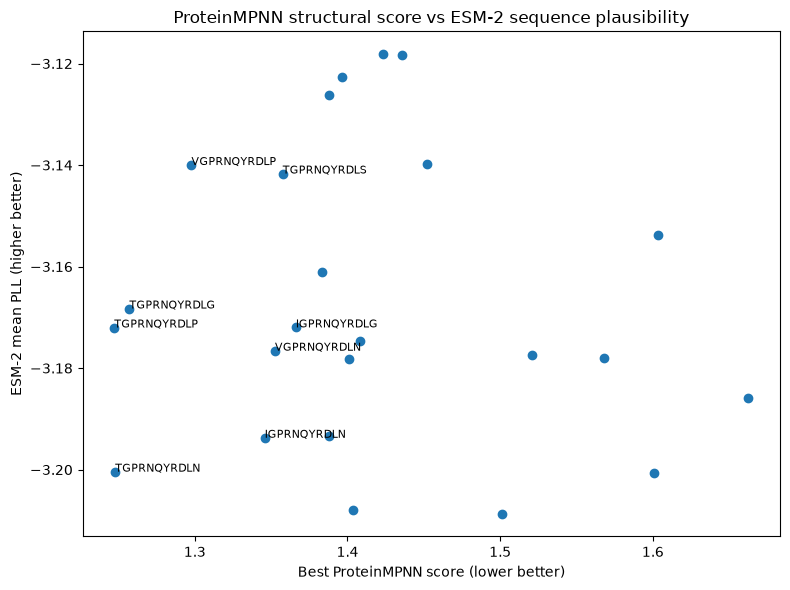

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    mpnn_scored_df[
        "best_ProteinMPNN_score"
    ],
    mpnn_scored_df[
        "ESM2_PLL_mean"
    ],
)

for _, row in mpnn_scored_df.head(8).iterrows():
    plt.annotate(
        row["peptide_sequence"],
        (
            row["best_ProteinMPNN_score"],
            row["ESM2_PLL_mean"],
        ),
        fontsize=8,
    )

plt.xlabel(
    "Best ProteinMPNN score (lower better)"
)
plt.ylabel(
    "ESM-2 mean PLL (higher better)"
)
plt.title(
    "ProteinMPNN structural score vs ESM-2 sequence plausibility"
)
plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "08c_ProteinMPNN_vs_ESM2.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 14. Build normalized descriptive components

The integrated score is deliberately simple and transparent:

```text
30% ProteinMPNN score
25% ESM-2 PLL
20% sampling frequency
25% locality to F0010
```

Directionality:

```text
lower ProteinMPNN score → better
higher ESM-2 PLL        → better
higher frequency        → better
lower Hamming distance  → better
```

This integrated score is **not** a physical energy and is used only for
candidate prioritization.


In [14]:
def normalize_positive(series):
    s = series.astype(float)

    if np.isclose(
        s.max(),
        s.min(),
    ):
        return pd.Series(
            np.ones(len(s)),
            index=s.index,
        )

    return (
        s - s.min()
    ) / (
        s.max() - s.min()
    )

def normalize_inverse(series):
    s = series.astype(float)

    if np.isclose(
        s.max(),
        s.min(),
    ):
        return pd.Series(
            np.ones(len(s)),
            index=s.index,
        )

    return (
        s.max() - s
    ) / (
        s.max() - s.min()
    )

rank_df = mpnn_scored_df[
    mpnn_scored_df[
        "within_allowed_locality"
    ]
].copy()

rank_df[
    "component_ProteinMPNN"
] = normalize_inverse(
    rank_df[
        "best_ProteinMPNN_score"
    ]
)

rank_df[
    "component_ESM2"
] = normalize_positive(
    rank_df[
        "ESM2_PLL_mean"
    ]
)

rank_df[
    "component_frequency"
] = normalize_positive(
    rank_df[
        "sample_count"
    ]
)

rank_df[
    "component_locality"
] = normalize_inverse(
    rank_df[
        "hamming_vs_F0010_recalc"
    ]
)

rank_df[
    "AI_integrated_score"
] = (
    0.30
    * rank_df["component_ProteinMPNN"]
    + 0.25
    * rank_df["component_ESM2"]
    + 0.20
    * rank_df["component_frequency"]
    + 0.25
    * rank_df["component_locality"]
)

rank_df = (
    rank_df
    .sort_values(
        "AI_integrated_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

rank_df.insert(
    0,
    "AI_rank",
    np.arange(len(rank_df)) + 1,
)

rank_df.to_csv(
    TABLE_DIR
    / "08c_AI_integrated_ranking.csv",
    index=False,
)

display(
    rank_df[
        [
            "AI_rank",
            "peptide_sequence",
            "mutations_vs_F0010",
            "AI_integrated_score",
            "best_ProteinMPNN_score",
            "sample_count",
            "ESM2_PLL_mean",
            "hamming_vs_F0010_recalc",
            "seen_in_04c_local_dataset",
            "seen_in_prior_CLEAR_space",
        ]
    ]
    .head(30)
)


,AI_rank,peptide_sequence,mutations_vs_F0010,AI_integrated_score,best_ProteinMPNN_score,sample_count,ESM2_PLL_mean,hamming_vs_F0010_recalc,seen_in_04c_local_dataset,seen_in_prior_CLEAR_space
0,1,TGPRNQYRDLP,I1T+E3P+C5N+K11P,0.601249,1.2473,34,-3.172003,4,False,False
1,2,IGPRNQYRDLG,E3P+C5N+K11G,0.551163,1.3662,1,-3.171983,3,False,False
2,3,IGPRNQYRDLN,E3P+C5N+K11N,0.514333,1.3458,2,-3.193722,3,False,False
3,4,IGPRHQYRDLP,E3P+C5H+K11P,0.508830,1.4079,1,-3.174593,3,False,False
4,5,TGPRNQYRDLG,I1T+E3P+C5N+K11G,0.482043,1.2572,14,-3.168259,4,False,False
5,6,IGPRNQYRDLP,E3P+C5N+K11P,0.473701,1.3881,1,-3.193340,3,False,False
6,7,TGPRNQYRDLN,I1T+E3P+C5N+K11N,0.467732,1.2479,25,-3.200399,4,False,False
7,8,VGPRNQYRDLP,I1V+E3P+C5N+K11P,0.459301,1.2978,3,-3.139989,4,False,False
8,9,VGPRNQYRDLG,I1V+E3P+C5N+K11G,0.412233,1.3965,1,-3.122553,4,False,False
9,10,TGPRHQYRDLP,I1T+E3P+C5H+K11P,0.409406,1.3882,1,-3.126106,4,False,False


## 15. Identify genuinely novel ProteinMPNN proposals

In [15]:
rank_df[
    "novel_vs_04c_and_CLEAR"
] = (
    ~rank_df[
        "seen_in_04c_local_dataset"
    ].astype(bool)
    & ~rank_df[
        "seen_in_prior_CLEAR_space"
    ].astype(bool)
)

novel_df = (
    rank_df[
        rank_df[
            "novel_vs_04c_and_CLEAR"
        ]
    ]
    .copy()
)

print(
    "Novel ProteinMPNN sequences:",
    len(novel_df),
)

display(
    novel_df[
        [
            "AI_rank",
            "peptide_sequence",
            "mutations_vs_F0010",
            "AI_integrated_score",
            "ESM2_PLL_mean",
            "best_ProteinMPNN_score",
            "sample_count",
            "hamming_vs_F0010_recalc",
        ]
    ]
    .head(30)
)


Novel ProteinMPNN sequences: 23


,AI_rank,peptide_sequence,mutations_vs_F0010,AI_integrated_score,ESM2_PLL_mean,best_ProteinMPNN_score,sample_count,hamming_vs_F0010_recalc
0,1,TGPRNQYRDLP,I1T+E3P+C5N+K11P,0.601249,-3.172003,1.2473,34,4
1,2,IGPRNQYRDLG,E3P+C5N+K11G,0.551163,-3.171983,1.3662,1,3
2,3,IGPRNQYRDLN,E3P+C5N+K11N,0.514333,-3.193722,1.3458,2,3
3,4,IGPRHQYRDLP,E3P+C5H+K11P,0.508830,-3.174593,1.4079,1,3
4,5,TGPRNQYRDLG,I1T+E3P+C5N+K11G,0.482043,-3.168259,1.2572,14,4
5,6,IGPRNQYRDLP,E3P+C5N+K11P,0.473701,-3.193340,1.3881,1,3
6,7,TGPRNQYRDLN,I1T+E3P+C5N+K11N,0.467732,-3.200399,1.2479,25,4
7,8,VGPRNQYRDLP,I1V+E3P+C5N+K11P,0.459301,-3.139989,1.2978,3,4
8,9,VGPRNQYRDLG,I1V+E3P+C5N+K11G,0.412233,-3.122553,1.3965,1,4
9,10,TGPRHQYRDLP,I1T+E3P+C5H+K11P,0.409406,-3.126106,1.3882,1,4


## 16. Final shortlist selection policy

The final shortlist intentionally mixes complementary candidates:

1. **best integrated ProteinMPNN/ESM-2 design**;
2. **best conservative design** with Hamming distance ≤3;
3. **best ESM-2 novel design**;
4. additional high-ranking novel designs until reaching 3–5 total candidates.

Duplicate sequences are never selected twice.


In [16]:
selected = []
selection_reasons = []

def add_candidate(
    row,
    reason,
):
    seq = row[
        "peptide_sequence"
    ]

    if seq in selected:
        return

    if len(selected) >= N_FINAL_MAX:
        return

    selected.append(
        seq
    )

    selection_reasons.append({
        "peptide_sequence": seq,
        "selection_reason": reason,
    })


# 1. Best integrated design.
if len(rank_df):
    add_candidate(
        rank_df.iloc[0],
        "best integrated ProteinMPNN + ESM2 + frequency + locality score",
    )


# 2. Best conservative design.
conservative_df = rank_df[
    rank_df[
        "hamming_vs_F0010_recalc"
    ]
    <= MAX_HAMMING_CONSERVATIVE
]

if len(conservative_df):
    add_candidate(
        conservative_df.iloc[0],
        "best integrated conservative design (Hamming <= 3)",
    )


# 3. Best ESM-2 novel design.
if len(novel_df):
    best_esm_novel = (
        novel_df
        .sort_values(
            "ESM2_PLL_mean",
            ascending=False,
        )
        .iloc[0]
    )

    add_candidate(
        best_esm_novel,
        "best ESM-2 score among novel ProteinMPNN designs",
    )


# 4. Fill with highest integrated novel designs.
for _, row in novel_df.iterrows():

    if len(selected) >= N_FINAL_MAX:
        break

    add_candidate(
        row,
        "high-ranking novel integrated design",
    )


# 5. Ensure at least 3 selections, if possible.
if len(selected) < N_FINAL_MIN:

    for _, row in rank_df.iterrows():

        if len(selected) >= N_FINAL_MIN:
            break

        add_candidate(
            row,
            "fallback high-ranking integrated design",
        )


selection_reason_df = pd.DataFrame(
    selection_reasons
)

shortlist_df = (
    rank_df[
        rank_df[
            "peptide_sequence"
        ]
        .isin(selected)
    ]
    .merge(
        selection_reason_df,
        on="peptide_sequence",
        how="left",
    )
)

# Preserve selection order rather than rank order.
order_map = {
    seq: i + 1
    for i, seq in enumerate(selected)
}

shortlist_df[
    "selection_order"
] = shortlist_df[
    "peptide_sequence"
].map(order_map)

shortlist_df = (
    shortlist_df
    .sort_values(
        "selection_order"
    )
    .reset_index(drop=True)
)

shortlist_df.insert(
    0,
    "candidate_id",
    [
        f"MPNN_NEW_{i+1:02d}"
        for i in range(len(shortlist_df))
    ],
)

shortlist_df.to_csv(
    TABLE_DIR
    / "08c_final_new_candidate_shortlist.csv",
    index=False,
)

display(
    shortlist_df[
        [
            "candidate_id",
            "peptide_sequence",
            "mutations_vs_F0010",
            "selection_reason",
            "AI_integrated_score",
            "best_ProteinMPNN_score",
            "sample_count",
            "ESM2_PLL_mean",
            "delta_ESM2_PLL_vs_F0010",
            "hamming_vs_F0010_recalc",
            "novel_vs_04c_and_CLEAR",
        ]
    ]
)


,candidate_id,peptide_sequence,mutations_vs_F0010,selection_reason,AI_integrated_score,best_ProteinMPNN_score,sample_count,ESM2_PLL_mean,delta_ESM2_PLL_vs_F0010,hamming_vs_F0010_recalc,novel_vs_04c_and_CLEAR
0,MPNN_NEW_01,TGPRNQYRDLP,I1T+E3P+C5N+K11P,best integrated ProteinMPNN + ESM2 + frequency...,0.601249,1.2473,34,-3.172003,0.068178,4,True
1,MPNN_NEW_02,IGPRNQYRDLG,E3P+C5N+K11G,best integrated conservative design (Hamming <...,0.551163,1.3662,1,-3.171983,0.068198,3,True
2,MPNN_NEW_03,PGPRNQYRDLP,I1P+E3P+C5N+K11P,best ESM-2 score among novel ProteinMPNN designs,0.401600,1.4235,1,-3.118172,0.122009,4,True
3,MPNN_NEW_04,IGPRNQYRDLN,E3P+C5N+K11N,high-ranking novel integrated design,0.514333,1.3458,2,-3.193722,0.046458,3,True
4,MPNN_NEW_05,IGPRHQYRDLP,E3P+C5H+K11P,high-ranking novel integrated design,0.508830,1.4079,1,-3.174593,0.065588,3,True


## 17. Compare shortlist with F0010, CF06 and CF02

In [17]:
core_comparison_df = (
    reference_esm_df[
        [
            "candidate",
            "sequence",
            "ESM2_PLL_mean",
            "ESM2_pseudo_perplexity",
        ]
    ]
    .copy()
)

core_comparison_df[
    "category"
] = "established_PEArL_candidate"

shortlist_compare_df = pd.DataFrame({
    "candidate": shortlist_df[
        "candidate_id"
    ],
    "sequence": shortlist_df[
        "peptide_sequence"
    ],
    "ESM2_PLL_mean": shortlist_df[
        "ESM2_PLL_mean"
    ],
    "ESM2_pseudo_perplexity": shortlist_df[
        "ESM2_pseudo_perplexity"
    ],
    "category": "new_ProteinMPNN_candidate",
})

comparison_df = pd.concat(
    [
        core_comparison_df,
        shortlist_compare_df,
    ],
    ignore_index=True,
)

comparison_df.to_csv(
    TABLE_DIR
    / "08c_core_and_new_candidate_comparison.csv",
    index=False,
)

display(
    comparison_df.sort_values(
        "ESM2_PLL_mean",
        ascending=False,
    )
)


,candidate,sequence,ESM2_PLL_mean,ESM2_pseudo_perplexity,category
5,MPNN_NEW_03,PGPRNQYRDLP,-3.118172,22.605013,new_ProteinMPNN_candidate
2,CF02,IGERSQYRELK,-3.120088,22.648371,established_PEArL_candidate
4,MPNN_NEW_02,IGPRNQYRDLG,-3.171983,23.854738,new_ProteinMPNN_candidate
3,MPNN_NEW_01,TGPRNQYRDLP,-3.172003,23.855210,new_ProteinMPNN_candidate
7,MPNN_NEW_05,IGPRHQYRDLP,-3.174593,23.917084,new_ProteinMPNN_candidate
6,MPNN_NEW_04,IGPRNQYRDLN,-3.193722,24.379001,new_ProteinMPNN_candidate
1,CF06,IGERCQYRELR,-3.231630,25.320893,established_PEArL_candidate
0,F0010,IGERCQYRDLK,-3.240181,25.538332,established_PEArL_candidate


## 18. Add existing Pipeline 3 evidence for established candidates

Only F0010, CF06 and CF02 currently have downstream MD / endpoint-energy
evidence.

The new ProteinMPNN designs are intentionally left blank for these columns
until they are structurally validated.


In [18]:
DYNAMIC_FILE = (
    Path("outputs")
    / "pipeline_3_md_07d_selected_peptide_comparison"
    / "production_1ns"
    / "07d_selected_peptide_MD_comparison.csv"
)

ENERGY_FILE = (
    Path("outputs")
    / "pipeline_3_md_07e_mmgbsa_endpoint_comparison"
    / "tables"
    / "07e_endpoint_energy_summary.csv"
)

evidence_df = comparison_df.copy()

if DYNAMIC_FILE.exists():

    dyn = pd.read_csv(
        DYNAMIC_FILE
    )

    keep = [
        c for c in [
            "candidate",
            "mean_D_CA_RMSD_A",
            "mean_D_CA_RMSF_A",
            "n_persistent_contacts_50pct",
            "mean_contact_persistence",
        ]
        if c in dyn.columns
    ]

    evidence_df = evidence_df.merge(
        dyn[keep],
        on="candidate",
        how="left",
    )

if ENERGY_FILE.exists():

    ene = pd.read_csv(
        ENERGY_FILE
    )

    keep = [
        c for c in [
            "candidate",
            "energetic_rank",
            "mean_delta_E_endpoint_kcal_mol",
        ]
        if c in ene.columns
    ]

    evidence_df = evidence_df.merge(
        ene[keep],
        on="candidate",
        how="left",
    )

evidence_df.to_csv(
    TABLE_DIR
    / "08c_current_evidence_matrix.csv",
    index=False,
)

display(evidence_df)


,candidate,sequence,ESM2_PLL_mean,ESM2_pseudo_perplexity,category,mean_D_CA_RMSD_A,mean_D_CA_RMSF_A,n_persistent_contacts_50pct,mean_contact_persistence,energetic_rank,mean_delta_E_endpoint_kcal_mol
0,F0010,IGERCQYRDLK,-3.240181,25.538332,established_PEArL_candidate,1.965916,1.163706,43.0,0.540519,2.0,-59.457704
1,CF06,IGERCQYRELR,-3.231630,25.320893,established_PEArL_candidate,1.293427,0.903728,45.0,0.528545,1.0,-65.661216
2,CF02,IGERSQYRELK,-3.120088,22.648371,established_PEArL_candidate,0.901385,0.737052,43.0,0.602886,3.0,-56.619600
3,MPNN_NEW_01,TGPRNQYRDLP,-3.172003,23.855210,new_ProteinMPNN_candidate,NaN,NaN,NaN,NaN,NaN,NaN
4,MPNN_NEW_02,IGPRNQYRDLG,-3.171983,23.854738,new_ProteinMPNN_candidate,NaN,NaN,NaN,NaN,NaN,NaN
5,MPNN_NEW_03,PGPRNQYRDLP,-3.118172,22.605013,new_ProteinMPNN_candidate,NaN,NaN,NaN,NaN,NaN,NaN
6,MPNN_NEW_04,IGPRNQYRDLN,-3.193722,24.379001,new_ProteinMPNN_candidate,NaN,NaN,NaN,NaN,NaN,NaN
7,MPNN_NEW_05,IGPRHQYRDLP,-3.174593,23.917084,new_ProteinMPNN_candidate,NaN,NaN,NaN,NaN,NaN,NaN


## 19. ESM-2 embedding comparison

This is used only to visualize whether the new ProteinMPNN candidates remain
near the F0010/CF06/CF02 sequence representation space.


In [19]:
@torch.no_grad()
def esm2_embedding(
    sequence,
    label="peptide",
):
    _, _, tokens = batch_converter(
        [(label, sequence)]
    )

    tokens = tokens.to(
        DEVICE
    )

    result = model(
        tokens,
        repr_layers=[
            model.num_layers
        ],
        return_contacts=False,
    )

    residue_repr = (
        result[
            "representations"
        ][
            model.num_layers
        ][
            0,
            1:len(sequence) + 1,
            :,
        ]
    )

    return (
        residue_repr
        .mean(dim=0)
        .detach()
        .cpu()
        .numpy()
    )


In [20]:
embedding_input_df = (
    comparison_df[
        [
            "candidate",
            "sequence",
            "category",
        ]
    ]
    .drop_duplicates("sequence")
    .reset_index(drop=True)
)

embeddings = np.vstack([
    esm2_embedding(
        row["sequence"],
        row["candidate"],
    )
    for _, row in embedding_input_df.iterrows()
])

seed_idx = int(
    embedding_input_df.index[
        embedding_input_df[
            "candidate"
        ]
        == "F0010"
    ][0]
)

similarities = cosine_similarity(
    embeddings,
    embeddings[
        seed_idx:
        seed_idx + 1
    ],
).ravel()

embedding_input_df[
    "cosine_similarity_to_F0010"
] = similarities

pca = PCA(
    n_components=2
)

coords = pca.fit_transform(
    embeddings
)

embedding_input_df[
    "PC1"
] = coords[:, 0]

embedding_input_df[
    "PC2"
] = coords[:, 1]

embedding_input_df.to_csv(
    TABLE_DIR
    / "08c_ESM2_embedding_comparison.csv",
    index=False,
)

display(
    embedding_input_df.sort_values(
        "cosine_similarity_to_F0010",
        ascending=False,
    )
)


,candidate,sequence,category,cosine_similarity_to_F0010,PC1,PC2
0,F0010,IGERCQYRDLK,established_PEArL_candidate,1.000000,-0.670139,0.133900
1,CF06,IGERCQYRELR,established_PEArL_candidate,0.992827,-0.582196,0.601491
2,CF02,IGERSQYRELK,established_PEArL_candidate,0.990478,-0.701696,-0.227327
4,MPNN_NEW_02,IGPRNQYRDLG,new_ProteinMPNN_candidate,0.986674,0.030396,-0.356573
6,MPNN_NEW_04,IGPRNQYRDLN,new_ProteinMPNN_candidate,0.986472,-0.003764,-0.498934
3,MPNN_NEW_01,TGPRNQYRDLP,new_ProteinMPNN_candidate,0.978950,0.430734,-0.095025
7,MPNN_NEW_05,IGPRHQYRDLP,new_ProteinMPNN_candidate,0.969991,0.743877,0.313146
5,MPNN_NEW_03,PGPRNQYRDLP,new_ProteinMPNN_candidate,0.969600,0.752787,0.129322


## 20. Embedding PCA plot

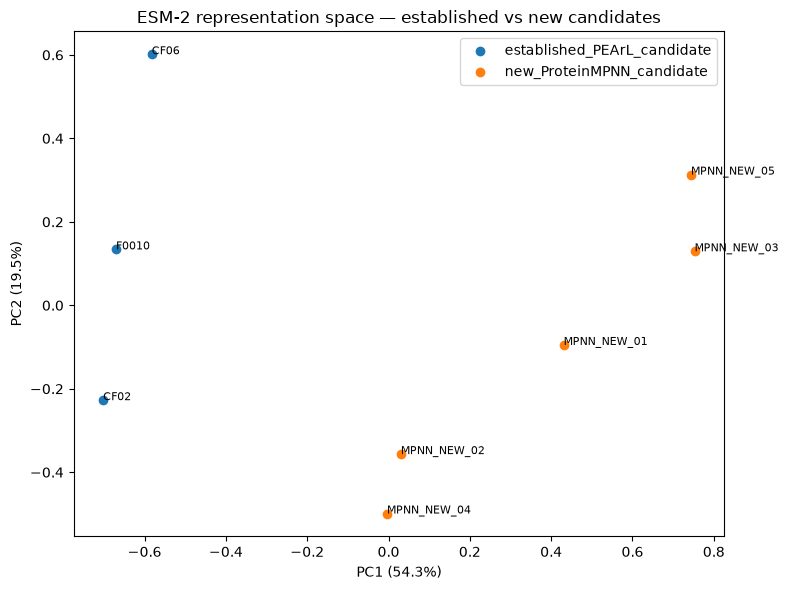

In [21]:
plt.figure(figsize=(8, 6))

for category in embedding_input_df[
    "category"
].unique():

    df = embedding_input_df[
        embedding_input_df[
            "category"
        ]
        == category
    ]

    plt.scatter(
        df["PC1"],
        df["PC2"],
        label=category,
    )

for _, row in embedding_input_df.iterrows():

    plt.annotate(
        row["candidate"],
        (
            row["PC1"],
            row["PC2"],
        ),
        fontsize=8,
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title(
    "ESM-2 representation space — established vs new candidates"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "08c_ESM2_embedding_shortlist_PCA.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 21. Final shortlist table for structural validation

In [22]:
validation_export_df = shortlist_df[
    [
        "candidate_id",
        "peptide_sequence",
        "mutations_vs_F0010",
        "hamming_vs_F0010_recalc",
        "best_ProteinMPNN_score",
        "mean_ProteinMPNN_score",
        "sample_count",
        "ESM2_PLL_mean",
        "ESM2_pseudo_perplexity",
        "delta_ESM2_PLL_vs_F0010",
        "AI_integrated_score",
        "seen_in_04c_local_dataset",
        "seen_in_prior_CLEAR_space",
        "novel_vs_04c_and_CLEAR",
        "selection_reason",
    ]
].copy()

validation_export_df.to_csv(
    TABLE_DIR
    / "08c_candidates_for_structural_validation.csv",
    index=False,
)

display(validation_export_df)


,candidate_id,peptide_sequence,mutations_vs_F0010,hamming_vs_F0010_recalc,best_ProteinMPNN_score,mean_ProteinMPNN_score,sample_count,ESM2_PLL_mean,ESM2_pseudo_perplexity,delta_ESM2_PLL_vs_F0010,AI_integrated_score,seen_in_04c_local_dataset,seen_in_prior_CLEAR_space,novel_vs_04c_and_CLEAR,selection_reason
0,MPNN_NEW_01,TGPRNQYRDLP,I1T+E3P+C5N+K11P,4,1.2473,1.300118,34,-3.172003,23.855210,0.068178,0.601249,False,False,True,best integrated ProteinMPNN + ESM2 + frequency...
1,MPNN_NEW_02,IGPRNQYRDLG,E3P+C5N+K11G,3,1.3662,1.366200,1,-3.171983,23.854738,0.068198,0.551163,False,False,True,best integrated conservative design (Hamming <...
2,MPNN_NEW_03,PGPRNQYRDLP,I1P+E3P+C5N+K11P,4,1.4235,1.423500,1,-3.118172,22.605013,0.122009,0.401600,False,False,True,best ESM-2 score among novel ProteinMPNN designs
3,MPNN_NEW_04,IGPRNQYRDLN,E3P+C5N+K11N,3,1.3458,1.374800,2,-3.193722,24.379001,0.046458,0.514333,False,False,True,high-ranking novel integrated design
4,MPNN_NEW_05,IGPRHQYRDLP,E3P+C5H+K11P,3,1.4079,1.407900,1,-3.174593,23.917084,0.065588,0.508830,False,False,True,high-ranking novel integrated design


## 22. Automatic QC

In [23]:
qc_rows = [
    {
        "check": "08b_production_loaded",
        "pass": len(mpnn_df) > 0,
    },
    {
        "check": "all_ProteinMPNN_sequences_valid",
        "pass": bool(
            mpnn_df[
                "valid_sequence"
            ].all()
        ),
    },
    {
        "check": "ESM2_scores_complete",
        "pass": bool(
            mpnn_scored_df[
                "ESM2_PLL_mean"
            ].notna().all()
        ),
    },
    {
        "check": "shortlist_at_least_3",
        "pass": (
            len(shortlist_df)
            >= N_FINAL_MIN
        ),
    },
    {
        "check": "shortlist_at_most_5",
        "pass": (
            len(shortlist_df)
            <= N_FINAL_MAX
        ),
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

ALL_QC_PASSED = bool(
    qc_df["pass"].all()
)

display(qc_df)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "08c_QC.csv",
    index=False,
)


,check,pass
0,08b_production_loaded,True
1,all_ProteinMPNN_sequences_valid,True
2,ESM2_scores_complete,True
3,shortlist_at_least_3,True
4,shortlist_at_most_5,True


ALL QC PASSED: True


## 23. Automatic report

In [24]:
report_lines = [
    "# 08c - ESM-2 + ProteinMPNN Integrated Candidate Selection",
    "",
    f"- ProteinMPNN unique designs evaluated: {len(mpnn_df)}",
    f"- ESM-2 model: {MODEL_NAME}",
    f"- Final new-candidate shortlist: {len(shortlist_df)}",
    "",
    "## Selected candidates",
]

for row in shortlist_df.itertuples():

    report_lines.append(
        (
            f"- {row.candidate_id}: {row.peptide_sequence} "
            f"({row.mutations_vs_F0010}); "
            f"Hamming={row.hamming_vs_F0010_recalc}; "
            f"ProteinMPNN best={row.best_ProteinMPNN_score:.4f}; "
            f"ESM2 PLL={row.ESM2_PLL_mean:.4f}; "
            f"AI integrated={row.AI_integrated_score:.4f}; "
            f"reason={row.selection_reason}"
        )
    )

report_lines.extend([
    "",
    "## Interpretation",
    (
        "The shortlist contains ProteinMPNN-derived proposals prioritized "
        "by structure-conditioned score, recurrence, ESM-2 plausibility "
        "and locality to F0010."
    ),
    (
        "These new candidates do not yet have the downstream FoldX, Rosetta, "
        "MD or endpoint-energy evidence available for CF06 and CF02."
    ),
    (
        "They should therefore be treated as hypotheses for structural "
        "validation rather than as replacements for the established leads."
    ),
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "08c_integrated_candidate_selection_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(report_text)
print(
    "\nReport:",
    report_path.resolve(),
)


# 08c - ESM-2 + ProteinMPNN Integrated Candidate Selection

- ProteinMPNN unique designs evaluated: 24
- ESM-2 model: esm2_t6_8M_UR50D
- Final new-candidate shortlist: 5

## Selected candidates
- MPNN_NEW_01: TGPRNQYRDLP (I1T+E3P+C5N+K11P); Hamming=4; ProteinMPNN best=1.2473; ESM2 PLL=-3.1720; AI integrated=0.6012; reason=best integrated ProteinMPNN + ESM2 + frequency + locality score
- MPNN_NEW_02: IGPRNQYRDLG (E3P+C5N+K11G); Hamming=3; ProteinMPNN best=1.3662; ESM2 PLL=-3.1720; AI integrated=0.5512; reason=best integrated conservative design (Hamming <= 3)
- MPNN_NEW_03: PGPRNQYRDLP (I1P+E3P+C5N+K11P); Hamming=4; ProteinMPNN best=1.4235; ESM2 PLL=-3.1182; AI integrated=0.4016; reason=best ESM-2 score among novel ProteinMPNN designs
- MPNN_NEW_04: IGPRNQYRDLN (E3P+C5N+K11N); Hamming=3; ProteinMPNN best=1.3458; ESM2 PLL=-3.1937; AI integrated=0.5143; reason=high-ranking novel integrated design
- MPNN_NEW_05: IGPRHQYRDLP (E3P+C5H+K11P); Hamming=3; ProteinMPNN best=1.4079; ESM2 PLL=-3.17

# 24. Next step

After 08c, Pipeline 4 has completed the main AI-generation stage:

```text
08a  ESM-2 plausibility
08b  ProteinMPNN inverse folding
08c  integrated AI candidate selection
```

The next notebook should structurally validate only the small 08c shortlist.

A natural next stage is:

```text
08d — ProteinMPNN Candidate FoldX/Rosetta Structural Validation
```

with:

```text
F0010 / CF06 / CF02 as established references
+
3–5 new MPNN candidates
```

The objective is to determine whether any genuinely new ProteinMPNN sequence
survives the same structural criteria already applied to the CLEAR candidates.

Only after that would it be sensible to consider additional MD for the best
new AI-derived candidate(s).
